# Multivariate Analysis

**Multivariate** means looking at **3 or more columns together** at the same time.

This is the most powerful EDA step — it shows hidden patterns that only appear when multiple columns are combined.

All 3 datasets are used here:
- `flights_merged.csv` → flights + users
- `hotels.csv` → hotel data

**7 Graphs:**
1. Heatmap — Correlation between all numeric columns
2. Scatter with Color — Price vs Distance, colored by Flight Type
3. Grouped Bar — Average Price by Flight Type × Agency
4. Pair Plot — Price, Time, Distance colored by Flight Type
5. Stacked Bar — Gender split across Flight Types (flights + users)
6. Multi-Line Graph — Monthly Price Trend for each Flight Type
7. Grouped Bar — Hotel Total Bill by City × Hotel Name (hotels)

# Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# finding project root
BASE_DIR = Path(os.getcwd())
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

# flights + users merged
df = pd.read_csv(BASE_DIR / "data" / "processed" / "flights_merged.csv")

# hotels — fresh from raw
hotels = pd.read_csv(BASE_DIR / "data" / "raw" / "hotels.csv")

# parsing date column back to datetime after loading from CSV
df["date"] = pd.to_datetime(df["date"])

print("flights+users :", df.shape)
print("hotels        :", hotels.shape)

flights+users : (271888, 12)
hotels        : (40552, 8)


All 3 datasets loaded — flights, users (inside df), and hotels ready.

## Graph 1 - Heatmap : Correlation Between Numeric Columns

A heatmap shows how strongly two numeric columns are related.
- Value close to **+1** → both go up together
- Value close to **-1** → one goes up, other goes down
- Value close to **0** → no relationship

I am checking price, time, distance and age all at once.

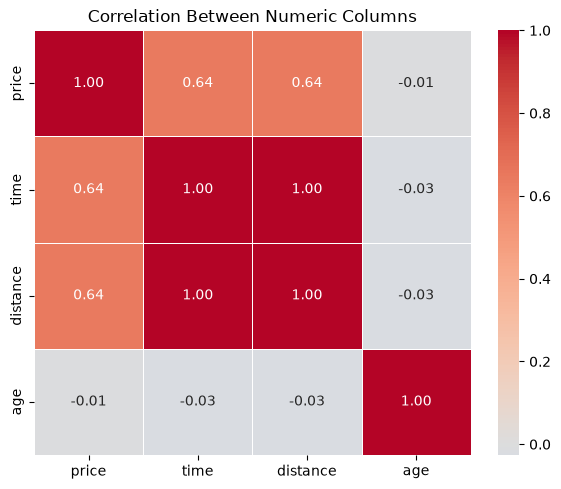

In [3]:
# picking only the numeric columns I care about
num_cols = ["price", "time", "distance", "age"]

# calculating correlation between every pair of columns
corr = df[num_cols].corr()

plt.figure(figsize=(6, 5))

# annot=True prints the number inside each box
# cmap coolwarm makes positive red and negative blue
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)

plt.title("Correlation Between Numeric Columns")
plt.tight_layout()
plt.show()

Price and distance have the strongest positive correlation the farther the flight, the higher the price tends to be.

## Graph 2 — Scatter Plot : Price vs Distance Colored by Flight Type

A scatter plot with color adds a third variable (flight type) using different dot colors.
This shows whether the price-distance relationship changes depending on flight class.

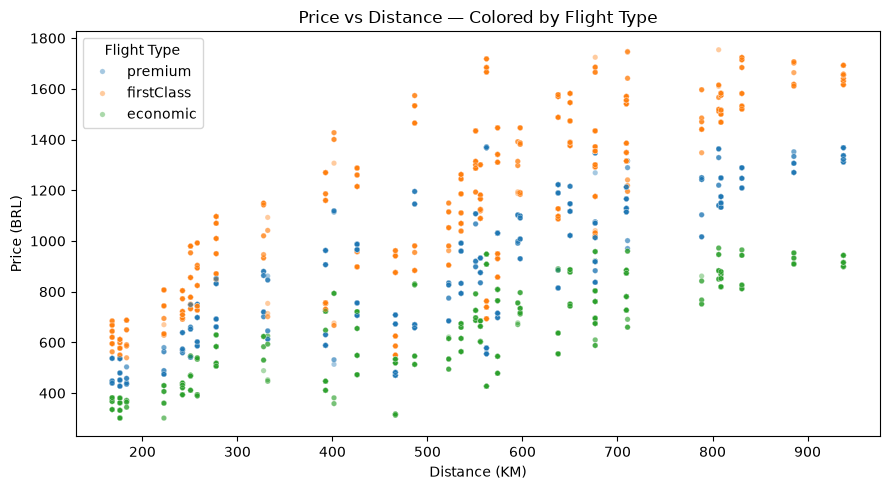

In [4]:
# sampling 4000 rows — plotting all 271k points would be very slow
sample = df.sample(4000, random_state=42)

plt.figure(figsize=(9, 5))

# hue="flightType" gives each flight class a different color automatically
sns.scatterplot(data=sample, x="distance", y="price",
                hue="flightType", alpha=0.4, s=15)

plt.title("Price vs Distance — Colored by Flight Type")
plt.xlabel("Distance (KM)")
plt.ylabel("Price (BRL)")
plt.legend(title="Flight Type")
plt.tight_layout()
plt.show()

First class dots sit clearly higher than economic dots at the same distance flight type shifts the entire price band upward.


## Graph 3 - Grouped Bar : Average Price by Flight Type × Agency

Each group of bars is one flight type, each bar inside the group is one agency.
This shows whether the same flight class costs differently depending on the agency.

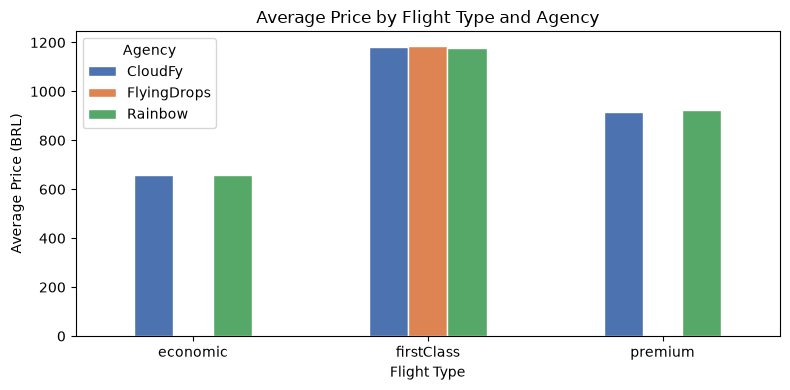

agency      CloudFy  FlyingDrops  Rainbow
flightType                               
economic     658.89          NaN   658.00
firstClass  1180.29      1186.16  1176.76
premium      916.13          NaN   924.62


In [5]:
# calculating average price for every flightType + agency combination
avg = df.groupby(["flightType", "agency"])["price"].mean().unstack()

avg.plot(kind="bar", figsize=(8, 4), edgecolor="white",
         color=["#4C72B0", "#DD8452", "#55A868"])

plt.title("Average Price by Flight Type and Agency")
plt.xlabel("Flight Type")
plt.ylabel("Average Price (BRL)")
plt.xticks(rotation=0)
plt.legend(title="Agency")
plt.tight_layout()
plt.show()

print(avg.round(2))

All three agencies charge roughly the same price for the same flight class agency alone does not affect price much.

## Graph 4 - Pair Plot : Price, Time, Distance by Flight Type

A pair plot creates a grid of scatter plots — every column against every other column.
The diagonal shows the distribution of each column.
Color shows flight type — so I can see patterns across multiple variables at once.

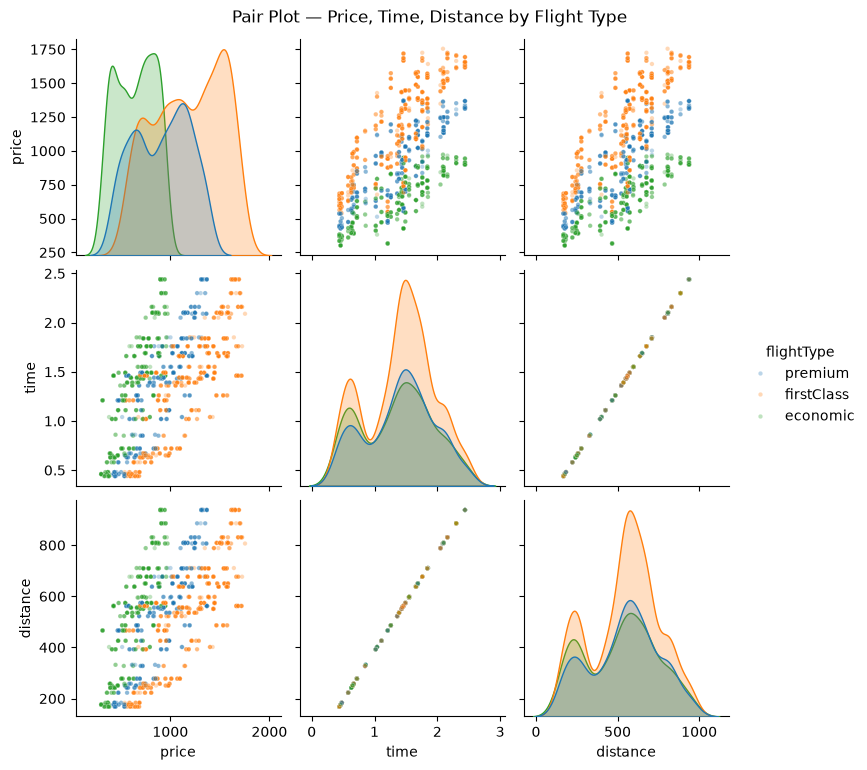

In [6]:
# sampling 2000 rows — pairplot is slow on large data
sample = df[["price", "time", "distance", "flightType"]].sample(2000, random_state=42)

g = sns.pairplot(
    sample,
    vars=["price", "time", "distance"],
    hue="flightType",
    plot_kws={"alpha": 0.3, "s": 10},
    diag_kind="kde"
)

g.fig.suptitle("Pair Plot — Price, Time, Distance by Flight Type", y=1.02)
plt.show()

Price and distance show a clear upward trend together, and first class separates from economic visually across all plots.

## Graph 5 - Stacked Bar : Gender Distribution Across Flight Types

This uses both flights and users data (gender comes from users.csv merged into df).
A stacked bar shows the gender composition inside each flight type category.

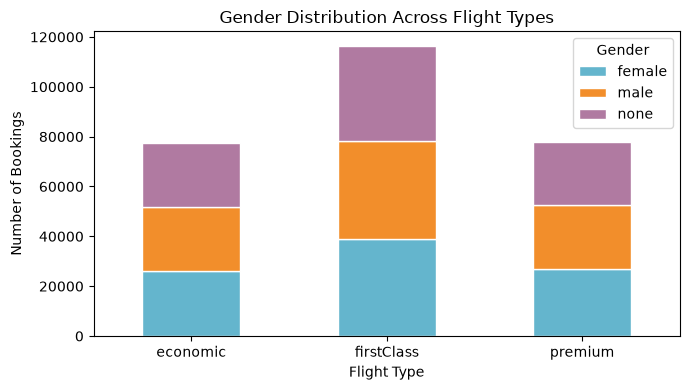

In [7]:
# crosstab counts how many of each gender booked each flight type
cross = pd.crosstab(df["flightType"], df["gender"])

cross.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 4),
    color=["#64B5CD", "#F28E2B", "#B07AA1"],
    edgecolor="white"
)

plt.title("Gender Distribution Across Flight Types")
plt.xlabel("Flight Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

Each flight class has almost the same male-female-none split gender does not influence which flight class a person chooses.

## Graph 6 - Multi-Line Graph : Monthly Price Trend per Flight Type

Three lines on one graph — one for each flight class.
This shows whether all classes follow the same seasonal price pattern or behave differently.

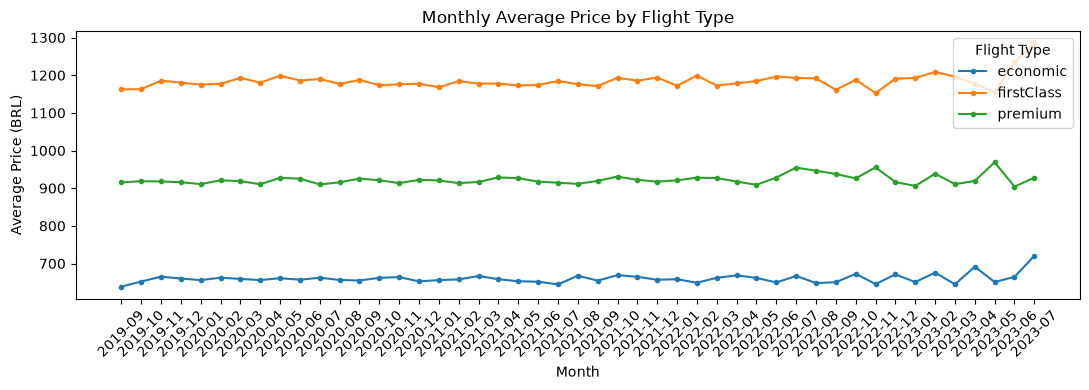

In [8]:
# extracting year-month from date
df["year_month"] = df["date"].dt.to_period("M").astype(str)

# average price per month per flight type — pivot makes each class a column
pivot = df.groupby(["year_month", "flightType"])["price"].mean().unstack()

plt.figure(figsize=(11, 4))

# plotting one line per flight type
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col],
             marker="o", markersize=3, linewidth=1.5, label=col)

plt.title("Monthly Average Price by Flight Type")
plt.xlabel("Month")
plt.ylabel("Average Price (BRL)")
plt.xticks(rotation=45)
plt.legend(title="Flight Type")
plt.tight_layout()
plt.show()

All three flight classes follow the same monthly trend when one class dips, the others dip too, showing the price is driven by time not class alone.

## Graph 7 - Grouped Bar : Hotel Total Bill by City × Hotel Name (hotels.csv)

Using only the hotels dataset here.
For each city, I want to see which hotel charges the most total bill on average.
This uses city and hotel name together — two categorical columns + one numeric.

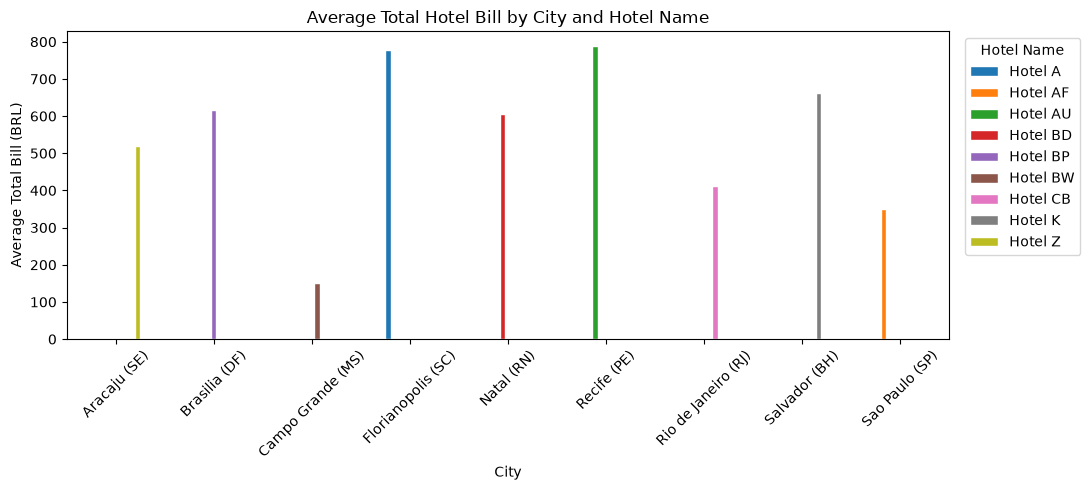

In [9]:
# average total bill per city × hotel name combination
avg_hotel = hotels.groupby(["place", "name"])["total"].mean().unstack()

avg_hotel.plot(
    kind="bar",
    figsize=(11, 5),
    edgecolor="white"
)

plt.title("Average Total Hotel Bill by City and Hotel Name")
plt.xlabel("City")
plt.ylabel("Average Total Bill (BRL)")
plt.xticks(rotation=45)
plt.legend(title="Hotel Name", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

The same hotel charges different total bills in different cities city and hotel name together determine the final cost, not just the hotel name alone.

## Summary

| Graph | Chart Type | Datasets | Key Finding |
|---|---|---|---|
| Correlation Heatmap | Heatmap | flights | Price and distance are most correlated |
| Price vs Distance | Scatter + Color | flights | Flight class shifts the entire price band |
| Price by Type × Agency | Grouped Bar | flights | Agency does not change price much |
| Pair Plot | Pair Plot | flights | Price-distance relationship is strongest |
| Gender × Flight Type | Stacked Bar | flights + users | Gender split is equal across all classes |
| Monthly Trend per Class | Multi-Line | flights | All classes follow the same seasonal pattern |
| Hotel Bill by City × Hotel | Grouped Bar | hotels | City and hotel name together drive total cost |

**EDA is complete.**